# Data cleaning and preprocessing

# I-Data cleaning

## 1-Data exploration

In [1]:
# import the libraies
import pandas as pd
import numpy as np
import sklearn
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt 
import seaborn as sns
print ('libraries imported')

libraries imported


In [2]:
# import the data set et defining the shape
data=pd.read_csv('creditcard.csv')
df=data
print(f'Our data set has {df.shape[0]} rows and {df.shape[1]} columns')

Our data set has 284807 rows and 31 columns


In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# cheking for data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

We can see that the time is in seconds. It is the number of seconds elapsed between this transaction and the first transaction outside of the amount and class

In [5]:
# Summary statistics
df.describe (include= 'all')

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## 2-Checking for duplicates

In [6]:
# Checking for duplicates
print(df.duplicated().sum())

1081


We have 1081 rows duplicated that we will remove

In [7]:
#Removing duplicates
df=df.drop_duplicates()
print(df.duplicated().sum())

0


## 3-Checking for missing values

In [8]:
#Count of missing values
missings=df.isnull().sum()
missings=missings.sort_values(ascending=False)

#missing proportions
missing_prop=df.isnull().sum()/len(df)*100
missing_prop=missing_prop.sort_values(ascending=False)

missing_table=pd.DataFrame({
    'count':missings,
    'proportion':missing_prop})

print(missing_table)

        count  proportion
Time        0         0.0
V16         0         0.0
Amount      0         0.0
V28         0         0.0
V27         0         0.0
V26         0         0.0
V25         0         0.0
V24         0         0.0
V23         0         0.0
V22         0         0.0
V21         0         0.0
V20         0         0.0
V19         0         0.0
V18         0         0.0
V17         0         0.0
V15         0         0.0
V1          0         0.0
V14         0         0.0
V13         0         0.0
V12         0         0.0
V11         0         0.0
V10         0         0.0
V9          0         0.0
V8          0         0.0
V7          0         0.0
V6          0         0.0
V5          0         0.0
V4          0         0.0
V3          0         0.0
V2          0         0.0
Class       0         0.0


We don't have missing values in our data set

## 3- feature engineering

In [9]:
## Transforming the "time" column in hours od the day
df['HourOfDay'] = (df['Time'] // 3600) % 24
df['HourOfDay'].describe()

C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_26820\3361495375.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['HourOfDay'] = (df['Time'] // 3600) % 24


count    283726.000000
mean         14.045646
std           5.834817
min           0.000000
25%          10.000000
50%          15.000000
75%          19.000000
max          23.000000
Name: HourOfDay, dtype: float64

## 4-Checking for outliers

In [10]:
## Detecting the outliers with the IQR range

def get_outlier_summary (df):
    
    #Create a copy of our data set
    df_clipped = df.copy()
    # Select the numerical columns to clip except the target
    numeric_cols_to_cap = df_clipped.select_dtypes(include=np.number).columns.drop('Class', errors='ignore')
    #loop on each numerical column
    summary_data = []
    for col in numeric_cols_to_cap:
        Q1=df_clipped[col].quantile(0.25)
        Q3=df_clipped[col].quantile(0.75)
        IQR=Q3-Q1
    
        #Defining the bounds
        lower_bound=Q1 - IQR * 1.5
        upper_bound=Q3 + IQR * 1.5
        num_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
        percent_outliers = (num_outliers / len(df)) * 100
        
        summary_data.append({
            'column': col,
            'num_outliers': num_outliers,
            'percent_outliers': percent_outliers,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound
        })
        
    return pd.DataFrame(summary_data).set_index('column').sort_values(by='num_outliers', ascending=False)

# Calling the function
outlier_summary_df = get_outlier_summary(df)
print("--- Outliers by column ---")
display(outlier_summary_df)

--- Outliers by column ---


,num_outliers,percent_outliers,lower_bound,upper_bound
column,,,,
V27,38799,13.674813,-0.313414,0.333982
Amount,31685,11.167464,-102.265000,185.375000
V28,30094,10.606712,-0.249459,0.274917
V20,27553,9.711130,-0.728484,0.650222
V8,23904,8.425030,-1.010627,1.127502
V6,22886,8.066233,-2.517765,2.145527
V23,18467,6.508744,-0.625881,0.611926
V12,15282,5.386182,-1.940959,2.151738
V21,14401,5.075672,-0.850053,0.807941


We can see that the columns with the biggest amount of outliers are  V27, Amount and V28

In [11]:
# We will try to characterize these outliers

def characterize_outliers(df, column_name):
    """
    Taking rows with outliers
    """
    # Apply the bound of our summary outlier table
    bounds = outlier_summary_df.loc[column_name]
    lower_bound = bounds['lower_bound']
    upper_bound = bounds['upper_bound']
    
    # Filter to retrieve rows with outliers
    outliers_df = df[(df[column_name] < lower_bound) | (df[column_name] > upper_bound)]
    
    if outliers_df.empty:
        print(f"No outliers found'{column_name}'.")
        return None
    
    print(f"--- Caractéristics of {len(outliers_df)} for the column '{column_name}' ---")
    
    # Déscribe the outliers
    outliers_description = outliers_df.describe()
    
    print("\nStatistics of outliers :")
    display(outliers_description)
    
    print("\nStatistics of all the data set :")
    display(df.describe())
    
    return outliers_description


characterize_outliers(df, 'V27');

--- Caractéristics of 38799 for the column 'V27' ---

Statistics of outliers :


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,HourOfDay
count,38799.000000,38799.000000,38799.000000,38799.000000,38799.000000,38799.000000,38799.000000,38799.000000,38799.000000,38799.000000,...,38799.000000,38799.000000,38799.000000,38799.000000,38799.000000,38799.000000,38799.000000,38799.000000,38799.000000,38799.000000
mean,97213.030722,-2.265333,0.437836,-0.268731,-0.085412,0.069968,0.087872,0.292275,-0.232843,0.214796,...,0.104876,-0.030748,0.016305,-0.106466,-0.006061,-0.069342,-0.041472,161.484434,0.008428,13.908013
std,47606.247152,2.803396,3.333672,2.261018,1.824212,2.427387,1.869063,2.445661,2.261781,1.475405,...,0.908272,1.449023,0.628616,0.681509,0.481345,1.022386,0.805516,552.910159,0.091418,6.070497
min,7.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-10.933144,-44.807735,-2.765519,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000,0.000000
25%,56758.500000,-2.784432,0.026111,-1.155467,-1.186221,-0.651634,-0.872632,-0.367767,-0.546389,-0.571154,...,-0.492377,-0.255987,-0.342871,-0.443724,-0.333679,-0.553794,-0.297334,4.000000,0.000000,10.000000
50%,91171.000000,-1.479619,0.960560,0.070692,-0.350382,0.191480,-0.245850,0.443179,-0.008633,0.040534,...,0.170802,-0.049535,0.054710,-0.115664,-0.048236,0.335375,0.018479,16.200000,0.000000,15.000000
75%,141031.000000,-0.732339,1.606699,1.163247,0.796306,0.969296,0.716826,1.043544,0.546189,0.809161,...,0.730170,0.175061,0.479818,0.249017,0.258348,0.472015,0.240962,71.800000,0.000000,19.000000
max,172786.000000,1.848436,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000,23.000000



Statistics of all the data set :


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,HourOfDay
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667,14.045646
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796,5.834817
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000,10.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000,15.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000,19.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000,23.000000


We can see that for the columns 'Amount for instance, the mean of a normal transactions is 88.47 instaed of 161.48 for the outliers in this column. Which is a big gap

In [12]:
# Visualizing the outliers with box plots

def plot_boxplots(df: pd.DataFrame, columns_to_plot: list):
    """
    Display a boxplot for each sepecified column
    """
    if not columns_to_plot:
        print("Give a list.")
        return

    print(f"Display of {len(columns_to_plot)} boxplots...\n")

    # loop for box plots
    for col in columns_to_plot:
        if col in df.columns:
            # box plot for each graph
            plt.figure(figsize=(10, 2)) 
            df.boxplot(column=[col], vert=False) 
            
            plt.title(f'Distribution of "{col}"')
            plt.show()
        else:
            print(f"Warning: the column {col} were not found.")
    


Display of 4 boxplots...



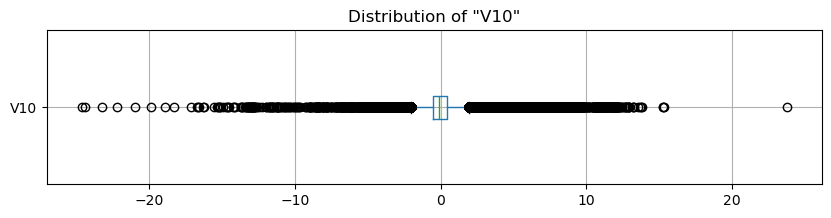

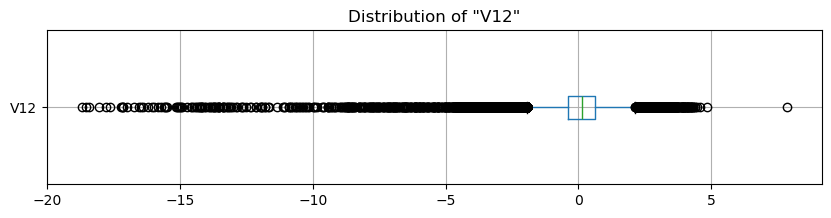

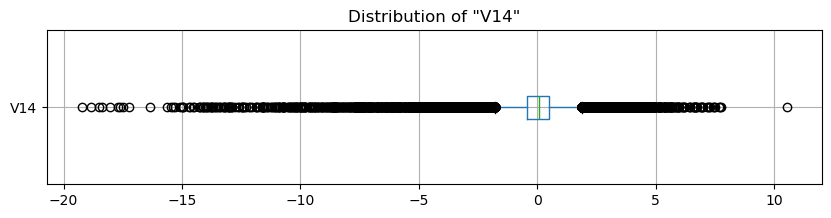

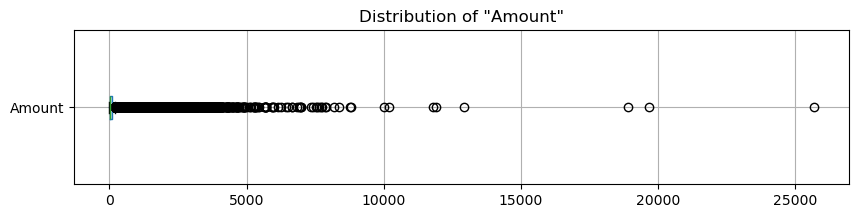

In [13]:
cols_to_check = ['V10', 'V12', 'V14', 'Amount']
# Use the function
plot_boxplots(df, cols_to_check)

There are a lot of point as outliers and we can see that the distribution will be skewed. A way to deal with that is to use standardization techniques as Standardscaler or robustScaler before implementing our machine learning algorithm

## II-Exploratory data analysis

### 1- Univariate analysis

In [14]:
# Analysis of the target feature'class'
Count=df['Class'].value_counts()
percent=(df['Class'].value_counts())/len (df) *100
class_table= pd.DataFrame({
    'count':Count,
    'percent': percent})

class_table

,count,percent
Class,,
0,283253,99.83329
1,473,0.16671


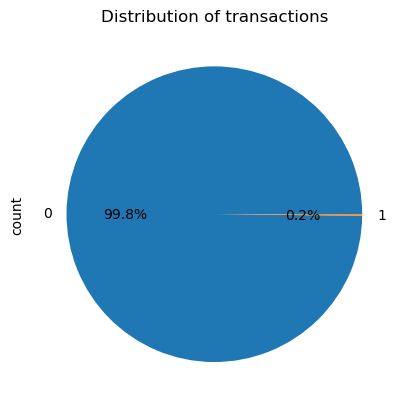

In [15]:
df['Class'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title ('Distribution of transactions')
plt.show()

The dataset is extremely unbalanced, with only 0.2% of transactions being fraudulent. This will have major implications on the choice of evaluation metric (accuracy vs. recall) and sampling techniques (e.g., SMOTE).

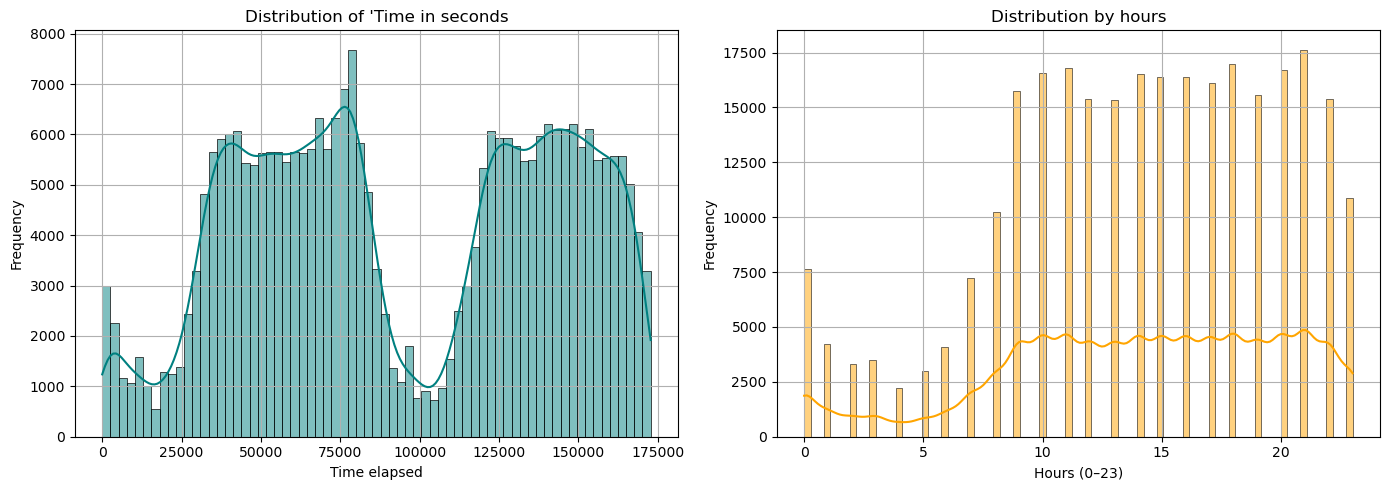

In [16]:
# Analysis the time variables
fig, axis = plt.subplots(1, 2, figsize=(14, 5))

# 1.  'Time' in seconds
sns.histplot(df['Time'], kde=True, ax=axis[0], color="teal")
axis[0].set_title("Distribution of 'Time in seconds")
axis[0].set_xlabel("Time elapsed")
axis[0].set_ylabel("Frequency")
axis[0].grid(True)

# 2. Time in hours
sns.histplot(df['HourOfDay'], kde=True, ax=axis[1], color="orange")
axis[1].set_title("Distribution by hours")
axis[1].set_xlabel("Hours (0–23)")
axis[1].set_ylabel("Frequency")
axis[1].grid(True)

plt.tight_layout()
plt.show()



We can see that we have more transactions after 10 hour and with pics after 20 hours

In [ ]:
# Analyzing the others numerical variables
numeric_cols=df.select_dtypes(include='number').columns.drop(['Time', 'Class', 'HourOfDay'], errors='ignore')
#Number of graphs
cols_per_row = 3
total_vars = len(numeric_cols)
rows_needed = int(np.ceil(total_vars / cols_per_row))

# Make the graphs
fig, axes = plt.subplots(rows_needed, cols_per_row, figsize=(5 * cols_per_row, 4 * rows_needed))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='cornflowerblue')
    axes[i].set_title(f'Distribution of "{col}"')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
    axes[i].grid(True)


for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
    

Most of the “V” variables appear to be centred around 0, confirming that they are the result of PCA. Some, such as Vxx and Vyy, have distributions that are not perfectly normal.

### 2 Bivariate analysis

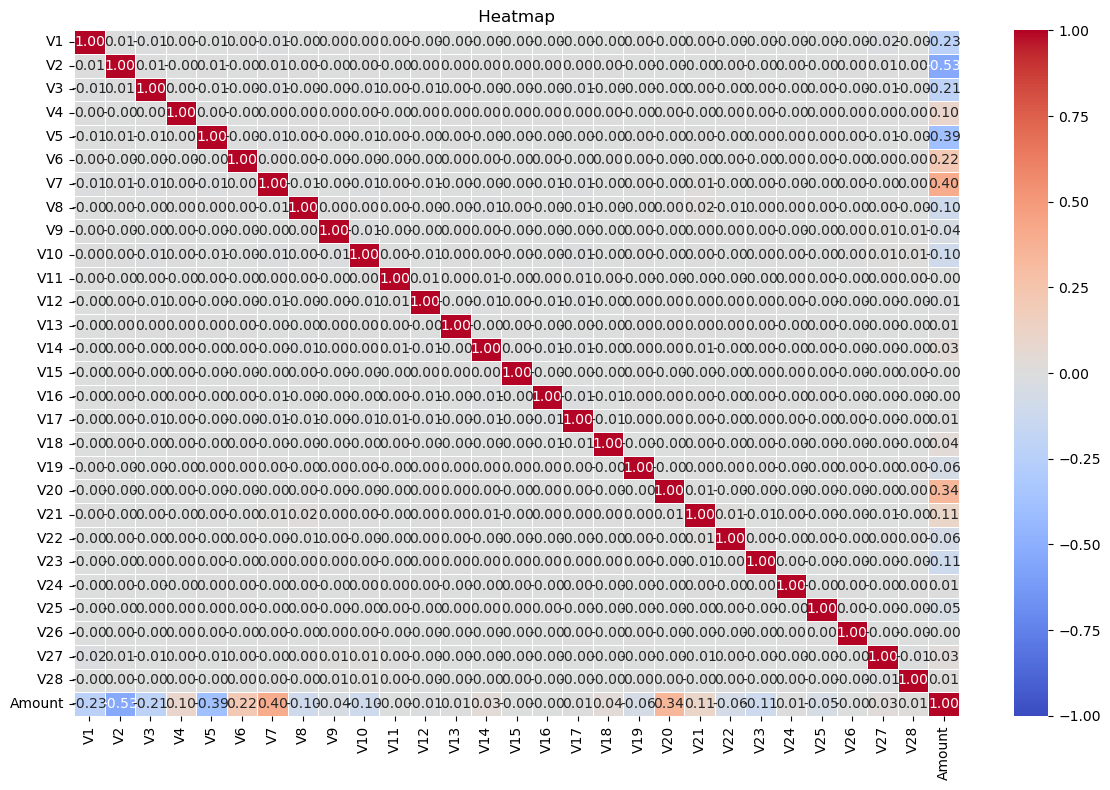

In [21]:
# Correlation matrix between the 'v' variables
numeric_cols=df.select_dtypes(include='number').drop(columns=['Time', 'Class', 'HourOfDay'], errors='ignore')
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title(" Heatmap ")
plt.tight_layout()
plt.show()


There is a negative correlation between V2/V5 and Amount, and a positive correlation between V7/V20 and Amount. Most of the V variables are uncorrelated with each other (which is expected after PCA), but there are still some weak correlations.

In [23]:
# Relationship between Amount, time and fraude
df_fraud=df[df['Class']==1]
df_non_fraud=df[df['Class']==0]

#Analyzing the statistics of amount in each data set
print(df_fraud['Amount'].describe())
print(df_non_fraud['Amount'].describe())

count     473.000000
mean      123.871860
std       260.211041
min         0.000000
25%         1.000000
50%         9.820000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64
count    283253.000000
mean         88.413575
std         250.379023
min           0.000000
25%           5.670000
50%          22.000000
75%          77.460000
max       25691.160000
Name: Amount, dtype: float64


Fraudulent transactions have a median amount higher than normal transactions.

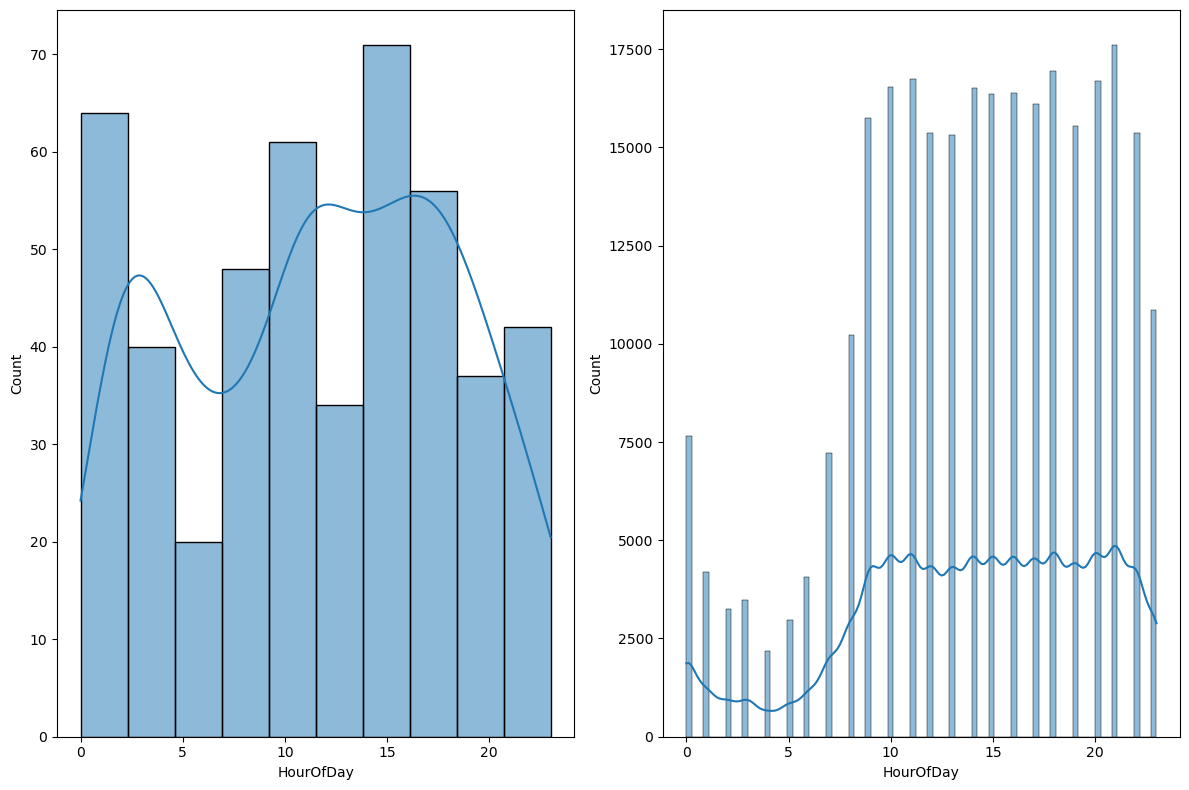

In [28]:
#Analyzing the statistics of Time in hours in each data set
fig, axis=plt.subplots(1, 2, figsize= (12, 8))
sns.histplot(df_fraud['HourOfDay'], kde=True, ax=axis[0])
sns.histplot(df_non_fraud['HourOfDay'], kde=True, ax=axis[1])
plt.tight_layout()
plt.show()

In [33]:
#Analyzing the statistics of other variables to characterize fraud and normal transactions
print(df_fraud.describe(include='all'))
print(df_non_fraud.describe(include='all'))

                Time          V1          V2          V3          V4  \
count     473.000000  473.000000  473.000000  473.000000  473.000000   
mean    80450.513742   -4.498280    3.405965   -6.729599    4.472591   
std     48636.179973    6.593145    4.122500    6.909647    2.871523   
min       406.000000  -30.552380   -8.402154  -31.103685   -1.313275   
25%     41203.000000   -5.603690    1.145381   -7.926507    2.288644   
50%     73408.000000   -2.271755    2.617105   -4.875397    4.100098   
75%    129095.000000   -0.361428    4.571743   -2.171454    6.290918   
max    170348.000000    2.132386   22.057729    2.250210   12.114672   

               V5          V6          V7          V8          V9  ...  \
count  473.000000  473.000000  473.000000  473.000000  473.000000  ...   
mean    -2.957197   -1.432518   -5.175912    0.953255   -2.522124  ...   
std      5.278831    1.715347    6.858024    5.585950    2.465047  ...   
min    -22.105532   -6.406267  -43.557242  -41.044261  

The distributions of certain variables, such as are radically different between fraudulent transactions and normal transactions. For example, most frauds have a very negative V1 value. These variables will be extremely important for the model.

The dataset is highly unbalanced.
Variables V10, V12, V14, and V17 appear to be the best predictors of fraud, as their distributions differ significantly between the two classes.
‘The Amount variable is highly skewed and could benefit from logarithmic transformation or robust scaling.’
‘Outliers are a key characteristic of fraud and should be retained.’


‘A tree-based model (Random Forest, XGBoost) should perform well because it can capture complex interactions and is robust to outliers.’
‘Feature engineering on the Time variable (e.g., creating morning/afternoon/night categories) could improve the model.’
‘Due to the imbalance, techniques such as oversampling (SMOTE) or the use of class weights (class_weight) will be necessary.’